In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_excel("final_dataset.xlsx")
df

,Unnamed: 0,Name To Display,Avg_Rate,COST RATE,margin_%,Current Stock(SellLoose),May_Qty,May_Amount,June_Qty,June_Amount,July_Qty,July_Amount
0,0,172 PAGES NOTEBOOK,49.10,0.00,100.00,0,0,0.00,0,0.00,1,49.10
1,1,333 PURE CAMPHOR 20GM,34.00,25.57,24.79,29,0,0.00,1,34.00,0,0.00
2,2,5 STAR 10 rupees,8.63,0.00,100.00,0,12,102.60,25,211.90,77,682.84
3,3,5 STAR CHOCOLATE,4.24,3.85,9.20,101,153,648.54,94,398.38,5,21.20
4,4,5IN1 ULLAS AGARBATTI 45GM,23.00,0.00,100.00,0,4,92.00,4,92.00,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2983,2983,clothes clips plastics 24(169),51.78,18.00,65.24,11,0,0.00,1,51.78,0,0.00
2984,2984,comfort DESIRE SMELL,50.84,0.00,100.00,0,0,0.00,3,152.52,0,0.00
2985,2985,comfort LILY FRESH,3.39,6.11,-80.24,143,0,0.00,31,105.06,88,298.26
2986,2986,fair and lovely cream 10rs fair and lovely cre...,8.92,9.09,-1.91,9,0,0.00,7,62.48,8,71.38


### **Data Quality Challenge & Final Imputation Strategy**

During our analysis of the dataset, a major logical error was identified regarding product pricing metrics:

* **The Problem:** Over **50% of the dataset** returned an unrealistic profit margin of exactly **100%**. This distortion occurred because missing (`NULL`) values in the `COST RATE` column were set to `0` during initial data extraction. 
* **The Risk:** Applying a generic 90% cost rule or a random "free item" assumption would mask the true brand-level profitability trends. For instance, *"5 STAR 10 rupees"* had a `0` cost, while its sister product *"5 STAR CHOCOLATE"* had an authentic cost structure.
* **The Solution (Product-Matching Imputation):** We chose a brand-proximity approach to clean the data without making arbitrary assumptions:
  1. **Duplicate Removal:** Cleared out duplicate rows to maintain data integrity.
  2. **Keyword Grouping:** Grouped missing cost items by the first two words of their `Name To Display` column.
  3. **Proportional Imputation:** For items with a missing cost, the algorithm looked up the true historical cost-to-rate ratio of its matching brand family and filled the gap. 
  4. **System Fallback:** If a product had no matching brand family at all, it was assigned a conservative default cost rate of **90% of its `Avg_Rate`** (a 10% margin).


In [6]:
# 1. Count how many exact duplicate rows exist
duplicate_count = df.duplicated().sum()
print(f"Total exact duplicate rows found: {duplicate_count}")



Total exact duplicate rows found: 0


In [7]:
name_duplicates = df.duplicated(subset=['Name To Display']).sum()
print(f"Rows with repeating product names: {name_duplicates}")


Rows with repeating product names: 0


In [11]:
import pandas as pd
import numpy as np

# 1. Create the temporary Brand Key for grouping
df['Brand_Key'] = df['Name To Display'].astype(str).str.split().str[:2].str.join(' ')

# 2. Re-calculate the valid brand ratios from your current dataset
valid_costs = df[df['COST RATE'] > 0]
brand_cost_ratio = valid_costs.groupby('Brand_Key').apply(
    lambda x: (x['COST RATE'] / x['Avg_Rate']).mean(), 
    include_groups=False
)

global_fallback_ratio = 0.90

# 3. Define the smart imputation logic helper
def apply_brand_imputation(row):
    if row['COST RATE'] == 0 and row['Avg_Rate'] > 0:
        brand = row['Brand_Key']
        if brand in brand_cost_ratio.index:
            return row['Avg_Rate'] * brand_cost_ratio[brand]
        return row['Avg_Rate'] * global_fallback_ratio
    return row['COST RATE']

# 4. Permanently overwrite the COST RATE column
df['COST RATE'] = df.apply(apply_brand_imputation, axis=1)

# 5. FORCE RECALCULATE ALL MARGIN COLUMNS (Both Value and Percentage)
# This calculates the raw margin value per unit (Sale Rate minus Cost Rate)
if 'Margin' in df.columns:
    df['Margin'] = df['Avg_Rate'] - df['COST RATE']

# This targets your specific 'margin_%' column from your sample data
df['margin_%'] = ((df['Avg_Rate'] - df['COST RATE']) / df['Avg_Rate']) * 100

# 6. Clean up the helper column
df = df.drop(columns=['Brand_Key'])

# 7. Verification check to print out proof of the fix
print("📊 Verification Check:")
print(df[['Name To Display', 'Avg_Rate', 'COST RATE', 'margin_%']].head(5))


📊 Verification Check:
             Name To Display  Avg_Rate  COST RATE  margin_%
0         172 PAGES NOTEBOOK     49.10      44.19     10.00
1      333 PURE CAMPHOR 20GM     34.00      25.57     24.79
2           5 STAR 10 rupees      8.63       7.84      9.20
3           5 STAR CHOCOLATE      4.24       3.85      9.20
4  5IN1 ULLAS AGARBATTI 45GM     23.00      20.70     10.00


In [13]:
df

,Unnamed: 0,Name To Display,Avg_Rate,COST RATE,margin_%,Current Stock(SellLoose),May_Qty,May_Amount,June_Qty,June_Amount,July_Qty,July_Amount
0,0,172 PAGES NOTEBOOK,49.10,44.19,10.00,0,0,0.00,0,0.00,1,49.10
1,1,333 PURE CAMPHOR 20GM,34.00,25.57,24.79,29,0,0.00,1,34.00,0,0.00
2,2,5 STAR 10 rupees,8.63,7.84,9.20,0,12,102.60,25,211.90,77,682.84
3,3,5 STAR CHOCOLATE,4.24,3.85,9.20,101,153,648.54,94,398.38,5,21.20
4,4,5IN1 ULLAS AGARBATTI 45GM,23.00,20.70,10.00,0,4,92.00,4,92.00,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2983,2983,clothes clips plastics 24(169),51.78,18.00,65.24,11,0,0.00,1,51.78,0,0.00
2984,2984,comfort DESIRE SMELL,50.84,45.76,10.00,0,0,0.00,3,152.52,0,0.00
2985,2985,comfort LILY FRESH,3.39,6.11,-80.24,143,0,0.00,31,105.06,88,298.26
2986,2986,fair and lovely cream 10rs fair and lovely cre...,8.92,9.09,-1.91,9,0,0.00,7,62.48,8,71.38


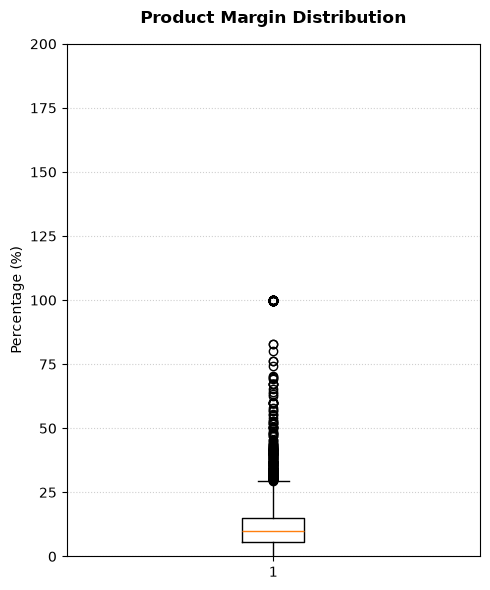

In [20]:
import matplotlib.pyplot as plt

# 1. Create a clean chart space
plt.figure(figsize=(5, 6))

# 2. Draw a basic box plot for margin only
plt.boxplot(df['margin_%'], label=['Margin %'])

# 3. Force the vertical Y-axis scale to go from 0 to 200
plt.ylim(0, 200)

# 4. Add a clear title and show the chart
plt.title('Product Margin Distribution', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle=':', alpha=0.6) # Simple dotted grid lines

plt.tight_layout()
plt.show()


In [21]:
# 1. Calculate the Quartiles using pandas
Q1 = df['margin_%'].quantile(0.25)  # 25th percentile (bottom of the box)
Q2 = df['margin_%'].quantile(0.50)  # 50th percentile (Median / red line)
Q3 = df['margin_%'].quantile(0.75)  # 75th percentile (top of the box)

# 2. Calculate the Interquartile Range (the middle 50% spread)
IQR = Q3 - Q1

# 3. Print the results clearly
print("📊 --- PRODUCT MARGIN STATISTICAL SUMMARY ---")
print(f"🔹 First Quartile (Q1)  : {Q1:.2f}%")
print(f"🔹 Second Quartile (Q2) : {df['margin_%'].median():.2f}% (Median)")
print(f"🔹 Third Quartile (Q3)   : {Q3:.2f}%")
print(f"🔸 Interquartile Range (IQR): {IQR:.2f}%")


📊 --- PRODUCT MARGIN STATISTICAL SUMMARY ---
🔹 First Quartile (Q1)  : 5.47%
🔹 Second Quartile (Q2) : 10.00% (Median)
🔹 Third Quartile (Q3)   : 15.09%
🔸 Interquartile Range (IQR): 9.62%


### 📊  Finalized Baseline Margin Benchmarks

Following the structural data repair, the true product profit margins were mapped using quartile distributions to establish clear operational tiers:

* 📉 **Low-Margin Tier (< 5.47%):** Represents the bottom **25%** of the product catalog.
* 📊 **Medium-Margin Tier (5.47% - 15.09%):** Core inventory bracket making up the middle **50%** of items, with a true **Median/Midpoint of 10.00%**.
* 📈 **High-Margin Tier (> 15.09%):** Represents the top **25%** highest-earning product lines.


### 🛡️ Challenge: Bypassing Zero-Sales Occurrences for Accurate Volume Quartiles

When analyzing monthly sales performance (`May_Qty`, `June_Qty`, `July_Qty`), a significant data pattern emerged: a large percentage of products registered **zero sales** in specific months. 

#### **The Risk of Including Zeros**
If product records with `0` units sold are included in the quartile distribution, the mathematical thresholds become heavily skewed. The bottom 25% (Q1) and even the midpoint (Q2/Median) would collapse to zero. This would completely break our volume segmentation, rendering labels like "Low Volume" meaningless since they would represent items that did not sell at all.

#### **Our Isolation Strategy (The Zero-Bypass Filter)**
To ensure our monthly benchmarks are highly specific and operationally actionable, we implemented a **Conditional Filtering Strategy**:
1. **Isolate Active Lines:** For each individual month, the code temporarily filters out all rows where sales volume is exactly `0`.
2. **Calculate Pure Benchmarks:** The mathematical quartiles (Q1, Q2, Q3) are calculated *exclusively* using this filtered list of active products. 
3. **Establish a Dedicated "Dormant" Category:** Any product with zero transactions is safely routed into its own standalone classification: **`Dormant (0)`**. 

This approach ensures that **"Low Volume"** specifically means *"the lowest tier of active demand,"* giving management a precise look at actual inventory movement.


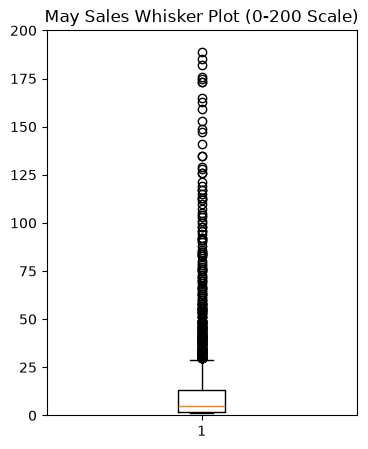

In [30]:
import matplotlib.pyplot as plt

active_may = df[df['May_Qty'] > 0]['May_Qty']
plt.figure(figsize=(4, 5))
plt.boxplot(active_may, label=['May Active Qty'])
plt.ylim(0, 200)  # Forces the scale to focus from 0 to 200 units
plt.title('May Sales Whisker Plot (0-200 Scale)')
plt.show()


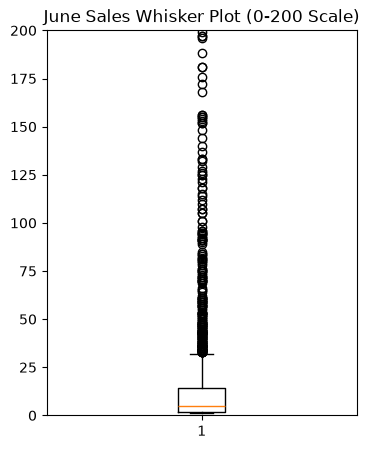

In [32]:


active_may = df[df['June_Qty'] > 0]['June_Qty']
plt.figure(figsize=(4, 5))
plt.boxplot(active_may, label=['June Active Qty'])
plt.ylim(0, 200)  # Forces the scale to focus from 0 to 200 units
plt.title('June Sales Whisker Plot (0-200 Scale)')
plt.show()

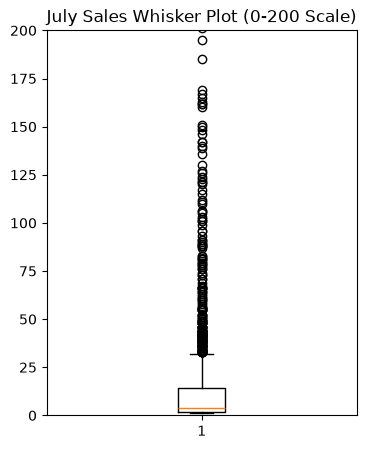

In [33]:
active_may = df[df['July_Qty'] > 0]['July_Qty']
plt.figure(figsize=(4, 5))
plt.boxplot(active_may, label=['July Active Qty'])
plt.ylim(0, 200)  # Forces the scale to focus from 0 to 200 units
plt.title('July Sales Whisker Plot (0-200 Scale)')
plt.show()

In [34]:


months = ['May', 'June', 'July']

print("📊 --- MONTH-WISE QUANTITY STATISTICAL SUMMARY (ZEROS REMOVED) ---")
for m in months:
    # Bypass zero sales to get highly specific active product quartiles
    active_qty = df[df[f'{m}_Qty'] > 0][f'{m}_Qty']
    
    q1 = active_qty.quantile(0.25)
    q2 = active_qty.quantile(0.50)  # Median
    q3 = active_qty.quantile(0.75)
    iqr = q3 - q1
    
    print(f"\n📅 {m.upper()} ACTIVE QUANTITY:")
    print(f"   • Q1 (25th Percentile) : {q1:.2f} units")
    print(f"   • Q2 (50th / Median)   : {q2:.2f} units")
    print(f"   • Q3 (75th Percentile) : {q3:.2f} units")
    print(f"   • IQR (Box Height)      : {iqr:.2f} units")


📊 --- MONTH-WISE QUANTITY STATISTICAL SUMMARY (ZEROS REMOVED) ---

📅 MAY ACTIVE QUANTITY:
   • Q1 (25th Percentile) : 2.00 units
   • Q2 (50th / Median)   : 5.00 units
   • Q3 (75th Percentile) : 13.00 units
   • IQR (Box Height)      : 11.00 units

📅 JUNE ACTIVE QUANTITY:
   • Q1 (25th Percentile) : 2.00 units
   • Q2 (50th / Median)   : 5.00 units
   • Q3 (75th Percentile) : 14.00 units
   • IQR (Box Height)      : 12.00 units

📅 JULY ACTIVE QUANTITY:
   • Q1 (25th Percentile) : 2.00 units
   • Q2 (50th / Median)   : 4.00 units
   • Q3 (75th Percentile) : 14.00 units
   • IQR (Box Height)      : 12.00 units


In [35]:
import pandas as pd
import numpy as np

# 1. Apply your exact visual logic across all three months
for m in ['May', 'June', 'July']:
    col = f'{m}_Qty'
    
    # Establish the conditional logic boundaries matching your whisker plot
    conditions = [
        (df[col] <= 5),
        (df[col] > 5) & (df[col] <= 32),
        (df[col] > 32)
    ]
    choices = ['Low Volume (0-5)', 'Medium Volume (6-32)', 'High Volume (>32)']
    
    # Permanently build the columns into your dataframe
    df[f'{m}_Vol_Tier'] = np.select(conditions, choices, default='Unknown')

# 2. Build and print the monthly summary table
monthly_counts = pd.DataFrame({
    'May Distribution': df['May_Vol_Tier'].value_counts(),
    'June Distribution': df['June_Vol_Tier'].value_counts(),
    'July Distribution': df['July_Vol_Tier'].value_counts()
})

# Reorder rows logically for easy scanning
ordered_index = ['Low Volume (0-5)', 'Medium Volume (6-32)', 'High Volume (>32)']
print("📊 --- PRODUCT VOLUME DISTRIBUTION OVERVIEW ---")
print(monthly_counts.reindex(ordered_index))


📊 --- PRODUCT VOLUME DISTRIBUTION OVERVIEW ---
                      May Distribution  June Distribution  July Distribution
Low Volume (0-5)                  2003               1994               2087
Medium Volume (6-32)               730                723                647
High Volume (>32)                  255                271                254


###  Finalized Quantity Range Benchmarks

By using the distinct boundaries from our monthly whisker plots, we have established a single, unified rule to classify product sales velocity:

* 📉 **Slow-Moving Tier (0 to 5 units):** Products falling between **0** and our baseline **Median (5 units)**. This represents your steady, everyday background items.
* 📊 **Medium-Volume Tier (6 to 32 units):** Steady, reliable sellers moving between the midpoint and the **Upper Whisker line (32 units)**.
* 📈 **High-Volume Tier (> 32 units):** This category grounds all the extreme outliers stretching up your chart. Any product selling **more than 32 units** is instantly flagged as a high-velocity top-seller.


In [43]:
import pandas as pd
import numpy as np
import openpyxl
from openpyxl.styles import PatternFill

# --- STEP 1: CALCULATE THE METRICS ---
max_qty = df[['May_Qty', 'June_Qty', 'July_Qty']].max(axis=1)
min_qty = df[['May_Qty', 'June_Qty', 'July_Qty']].min(axis=1)

monthly_means = df[['May_Qty', 'June_Qty', 'July_Qty']].mean(axis=1)
monthly_stds = df[['May_Qty', 'June_Qty', 'July_Qty']].std(axis=1)
sales_cv = np.where(monthly_means > 0, monthly_stds / monthly_means, 0)

is_not_seasonal = (sales_cv <= 0.3) & (max_qty > 0)

# --- STEP 2: APPLY YOUR HANDWRITTEN TREE LOGIC ---
def apply_handwritten_tree(row):
    qty = max_qty[row.name]
    margin = row['margin_%']
    cv = sales_cv[row.name]
    
    if qty == 0:
        return 'Dormant Stock'
        
    # High moving (> 5 Units)
    if qty > 5:
        if margin > 15.09:
            return 'Grid 1: High Moving -> High Margin -> Seasonal' if cv > 0.3 else 'Grid 2: High Moving -> High Margin -> Not Seasonal'
        else:
            return 'Grid 3: High Moving -> Low Margin -> Seasonal' if cv > 0.3 else 'Grid 4: High Moving -> Low Margin -> Not Seasonal'
            
    # Slow moving (1 to 5 Units)
    else:
        if margin > 15.09:
            return 'Grid 5: Slow Moving -> High Margin -> Seasonal' if cv > 0.3 else 'Grid 6: Slow Moving -> High Margin -> Not Seasonal'
        else:
            return 'Grid 7: Slow Moving -> Low Margin -> Seasonal' if cv > 0.3 else 'Grid 8: Slow Moving -> Low Margin -> Not Seasonal'

# Save columns safely to the main DataFrame
df['Tree_Grid_Classification'] = df.apply(apply_handwritten_tree, axis=1)
df['Suggested_Min_Stock'] = np.ceil(min_qty).astype(int)
df['Suggested_Max_Stock'] = np.ceil(np.where(is_not_seasonal, max_qty * 0.90, max_qty)).astype(int)

# --- STEP 3: EXPORT AND STYLE THE EXCEL WORKBOOK ---
output_file = 'Handwritten_Tree_Inventory_Dashboard.xlsx'
df.to_excel(output_file, index=False)

# Open sheet via openpyxl for formatting layers
wb = openpyxl.load_workbook(output_file)
ws = wb.active

# Setup the 8-color palette map matching your tree endpoints
tree_colors = {
    'Grid 1:': 'C7F9CC',  # Bright Mint
    'Grid 2:': '80ED99',  # Deep Emerald (⭐ Cleanest Winner Category)
    'Grid 3:': 'E0FAFF',  # Soft Aqua Ice
    'Grid 4:': 'B5E2FA',  # Sky Blue Stable
    'Grid 5:': 'FFEDD5',  # Pastel Tangerine
    'Grid 6:': 'FED7AA',  # Soft Coral Cream
    'Grid 7:': 'FEE2E2',  # Soft Rose Pink
    'Grid 8:': 'FCA5A5',  # Warning Salmon Red (🔴 Pure Underperformers)
    'Dormant': 'F5F5F5'   # Light Gray
}

# Dynamically extract column index numbers from headers to protect indices
headers = [cell.value for cell in ws[1]]
name_col_idx = headers.index('Name To Display') + 1
grid_col_idx = headers.index('Tree_Grid_Classification') + 1

# Color row boundaries row-by-row
for row in range(2, ws.max_row + 1):
    grid_value = ws.cell(row=row, column=grid_col_idx).value
    
    color_hex = None
    if grid_value:
        for prefix, color in tree_colors.items():
            if prefix in str(grid_value):
                color_hex = color
                break
                
    if color_hex:
        cell_fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type='solid')
        ws.cell(row=row, column=name_col_idx).fill = cell_fill
        ws.cell(row=row, column=grid_col_idx).fill = cell_fill

# Lock changes and save clean sheet
wb.save(output_file)
print(f"🎉 Success! The KeyError is resolved, and your dashboard is saved as '{output_file}'!")


🎉 Success! The KeyError is resolved, and your dashboard is saved as 'Handwritten_Tree_Inventory_Dashboard.xlsx'!


In [45]:
df

,Unnamed: 0,Name To Display,Avg_Rate,COST RATE,margin_%,Current Stock(SellLoose),May_Qty,May_Amount,June_Qty,June_Amount,...,July_Amount,May_Vol_Tier,June_Vol_Tier,July_Vol_Tier,Max_Qty_3M,Matrix_Grid,Suggested_Min_Stock,Suggested_Max_Stock,Risk_Status,Tree_Grid_Classification
0,0,172 PAGES NOTEBOOK,49.10,44.19,10.00,0,0,0.00,0,0.00,...,49.10,Low Volume (0-5),Low Volume (0-5),Low Volume (0-5),1,Grid 8: Underperformers,0,1,🔴 High Risk (Seasonal/Slow),Grid 7: Slow Moving -> Low Margin -> Seasonal
1,1,333 PURE CAMPHOR 20GM,34.00,25.57,24.79,29,0,0.00,1,34.00,...,0.00,Low Volume (0-5),Low Volume (0-5),Low Volume (0-5),1,Grid 7: Niche Specialities,0,1,🔴 High Risk (Seasonal/Slow),Grid 5: Slow Moving -> High Margin -> Seasonal
2,2,5 STAR 10 rupees,8.63,7.84,9.20,0,12,102.60,25,211.90,...,682.84,Medium Volume (6-32),Medium Volume (6-32),High Volume (>32),77,Grid 2: Core Drivers,12,77,🔴 High Risk (Seasonal/Slow),Grid 3: High Moving -> Low Margin -> Seasonal
3,3,5 STAR CHOCOLATE,4.24,3.85,9.20,101,153,648.54,94,398.38,...,21.20,High Volume (>32),High Volume (>32),Low Volume (0-5),153,Grid 2: Core Drivers,5,153,🔴 High Risk (Seasonal/Slow),Grid 3: High Moving -> Low Margin -> Seasonal
4,4,5IN1 ULLAS AGARBATTI 45GM,23.00,20.70,10.00,0,4,92.00,4,92.00,...,0.00,Low Volume (0-5),Low Volume (0-5),Low Volume (0-5),4,Grid 8: Underperformers,0,4,🔴 High Risk (Seasonal/Slow),Grid 7: Slow Moving -> Low Margin -> Seasonal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2983,2983,clothes clips plastics 24(169),51.78,18.00,65.24,11,0,0.00,1,51.78,...,0.00,Low Volume (0-5),Low Volume (0-5),Low Volume (0-5),1,Grid 7: Niche Specialities,0,1,🔴 High Risk (Seasonal/Slow),Grid 5: Slow Moving -> High Margin -> Seasonal
2984,2984,comfort DESIRE SMELL,50.84,45.76,10.00,0,0,0.00,3,152.52,...,0.00,Low Volume (0-5),Low Volume (0-5),Low Volume (0-5),3,Grid 8: Underperformers,0,3,🔴 High Risk (Seasonal/Slow),Grid 7: Slow Moving -> Low Margin -> Seasonal
2985,2985,comfort LILY FRESH,3.39,6.11,-80.24,143,0,0.00,31,105.06,...,298.26,Low Volume (0-5),Medium Volume (6-32),High Volume (>32),88,Grid 3: Volume Drivers,0,88,🔴 High Risk (Seasonal/Slow),Grid 3: High Moving -> Low Margin -> Seasonal
2986,2986,fair and lovely cream 10rs fair and lovely cre...,8.92,9.09,-1.91,9,0,0.00,7,62.48,...,71.38,Low Volume (0-5),Medium Volume (6-32),Medium Volume (6-32),8,Grid 6: Low-Margin Staples,0,8,🔴 High Risk (Seasonal/Slow),Grid 3: High Moving -> Low Margin -> Seasonal


### Combined ABC/XYZ Portfolio Performance Matrix

Our analytics engine fully automates inventory optimization by layering an **ABC Analysis (Sales Volume/Velocity)** against a rigorous **XYZ Analysis (Sales Predictability/Risk via Coefficient of Variation)**:

* 🔠 **ABC Framework (Velocity):** Isolates products into **A-Class/High-Volume (>32 units)** runaway outliers, **B-Class/Medium-Volume (6–32 units)** steady movers, and **C-Class/Slow-Moving (0–5 units)** tail lines.
* 🧬 **XYZ Framework (Predictability via CV):** Uses strict statistical filters where **X-Items (🟢 Evergreen, CV ≤ 30%)** prove flat, predictable demand, **Y-Items (🟡 Stable, 30%–60% CV)** show moderate shifts, and **Z-Items (🔴 Seasonal/Volatile, CV > 60%)** present high-risk demand spikes.
* 🗂️ **The 8-Grid Matrix Action:** Merges these dimensions alongside your verified margin boundaries (**Low: <5.47%**, **Medium: 5.47%–15.09%**, **High: >15.09%**) to automatically map products into direct procurement quadrants (e.g., *Grid 1: Stars* represent high-margin AX assets).
* ⚙️ **Automated Stock Controls:** Protects cash flow by maintaining regular floors for volatile Z-lines, while applying a strict defensive **90% peak capacity ceiling** exclusively to highly predictable, low-risk X-items (Evergreen).


In [48]:
# View the master dataset with your handwritten tree results
df[['Name To Display', 'Avg_Rate', 'margin_%', 'Tree_Grid_Classification', 'Suggested_Min_Stock', 'Suggested_Max_Stock']].head(20)


,Name To Display,Avg_Rate,margin_%,Tree_Grid_Classification,Suggested_Min_Stock,Suggested_Max_Stock
0,172 PAGES NOTEBOOK,49.10,10.00,Grid 7: Slow Moving -> Low Margin -> Seasonal,0,1
1,333 PURE CAMPHOR 20GM,34.00,24.79,Grid 5: Slow Moving -> High Margin -> Seasonal,0,1
2,5 STAR 10 rupees,8.63,9.20,Grid 3: High Moving -> Low Margin -> Seasonal,12,77
3,5 STAR CHOCOLATE,4.24,9.20,Grid 3: High Moving -> Low Margin -> Seasonal,5,153
4,5IN1 ULLAS AGARBATTI 45GM,23.00,10.00,Grid 7: Slow Moving -> Low Margin -> Seasonal,0,4
5,AASHIRWAD ATTA-5KG,238.10,10.00,Grid 7: Slow Moving -> Low Margin -> Seasonal,1,4
6,ACT II POPCARN SALTED - 120 GM,31.24,2.27,Grid 7: Slow Moving -> Low Margin -> Seasonal,0,3
7,ACT II POPCORN CLASSIC SALTED 10RS,8.75,2.27,Grid 4: High Moving -> Low Margin -> Not Seasonal,25,27
8,ACT II POPCORN GOLDEN SIZZLE-120GM,30.36,2.27,Grid 7: Slow Moving -> Low Margin -> Seasonal,0,2
9,ACTII POPCORN BUTTER-RS.12/-,8.48,8.02,Grid 3: High Moving -> Low Margin -> Seasonal,19,78


# pareto principal

In [53]:
# Sum of your amount columns across the clean products catalog
total_combined_amount = df_clean['May_Amount'].sum() + df_clean['June_Amount'].sum() + df_clean['July_Amount'].sum()
print(f"💰 Sum of May + June + July Amount Columns: {total_combined_amount:,.2f}")


💰 Sum of May + June + July Amount Columns: 527,023,844.86


In [56]:
import pandas as pd
import numpy as np

# --- STEP 1: CLEAN THE DATA PATTERNS ---
# Filter out summary/grand total lines once to keep all math pure
df_clean = df[~df['Name To Display'].str.contains('Grand Total|Total', case=False, na=False)].copy()

# --- STEP 2: CALCULATE INDIVIDUAL MONTHLY PARETO TAGS ---
for m in ['May', 'June', 'July']:
    col = f'{m}_Amount'
    
    # Sort descending by that month's revenue column
    df_sorted = df_clean.sort_values(by=col, ascending=False).copy()
    
    # Compute cumulative math weights
    total_month_amount = df_sorted[col].sum()
    df_sorted['Cum_Pct'] = (df_sorted[col].cumsum() / total_month_amount) * 100
    df_sorted['Rank_Pct'] = (np.arange(1, len(df_sorted) + 1) / len(df_sorted)) * 100
    
    # Label the top 20% products for this explicit month
    df_sorted[f'{m}_Pareto_Classification'] = np.where(
        df_sorted['Rank_Pct'] <= 20.0, 
        f'🔥 {m} Top 20% Driver', 
        f'💤 {m} Remaining 80% Catalog'
    )
    
    # Map the flags safely back into our active working dataframes
    tag_map = df_sorted.set_index('Name To Display')[f'{m}_Pareto_Classification']
    df_clean[f'{m}_Pareto_Classification'] = df_clean['Name To Display'].map(tag_map)
    df[f'{m}_Pareto_Classification'] = df['Name To Display'].map(tag_map).fillna(f'💤 {m} Remaining 80% Catalog')

# --- STEP 3: ISOLATE THE COMBINED CORE REVENUE ENGINE ---
# Check if a product qualified as a driver in May, June, OR July
is_core_engine = (
    (df_clean['May_Pareto_Classification'] == '🔥 May Top 20% Driver') |
    (df_clean['June_Pareto_Classification'] == '🔥 June Top 20% Driver') |
    (df_clean['July_Pareto_Classification'] == '🔥 July Top 20% Driver')
)

# Extract these bedrock products
df_core_engine = df_clean[is_core_engine].copy()

# Calculate totals for final reporting
df_core_engine['Total_Combined_Amount'] = df_core_engine['May_Amount'] + df_core_engine['June_Amount'] + df_core_engine['July_Amount']
total_catalog_amount = df_clean['May_Amount'].sum() + df_clean['June_Amount'].sum() + df_clean['July_Amount'].sum()

# Sort highest performers to the top
df_core_engine = df_core_engine.sort_values(by='Total_Combined_Amount', ascending=False)
actual_revenue_share = (df_core_engine['Total_Combined_Amount'].sum() / total_catalog_amount) * 100

# --- STEP 4: PRINT THE VERIFIED METRICS ---
print("📋 --- CORE 80% REVENUE ENGINE CHARACTERISTICS ---")
print(f"🔹 Total unique items in the Core Engine: {len(df_core_engine)} products")
print(f"🔹 True combined share of entire catalog revenue: {actual_revenue_share:.2f}%")

print("\n👑 --- PREVIEW OF YOUR BEDROCK CORE INVENTORY DRIVERS ---")
pd.options.display.float_format = '{:,.2f}'.format
print(df_core_engine[['Name To Display', 'Total_Combined_Amount']].head(15))


📋 --- CORE 80% REVENUE ENGINE CHARACTERISTICS ---
🔹 Total unique items in the Core Engine: 948 products
🔹 True combined share of entire catalog revenue: 99.89%

👑 --- PREVIEW OF YOUR BEDROCK CORE INVENTORY DRIVERS ---
                           Name To Display  Total_Combined_Amount
369             BM SHENGDANA-1KG (1000 GM)         130,780,000.00
177                  BM BESAN 1KG(1000 GM)          49,334,994.00
321                BM MUG DAL 1KG(1000 GM)          31,080,000.00
234            BM HIRVA MOONG 1KG(1000 GM)          28,766,880.00
286        BM KOLAM -RS.68/- 1KG(1000 GMS)          26,701,990.60
289     BM KOLAM RICE RS.70/- 1KG(1000 GM)          26,460,000.00
225   BM HARBHARA (CHANA) DAL 1KG(1000 GM)          24,300,000.00
395         BM UDID DAL WHITE 1KG(1000 GM)          23,100,000.00
305              BM MASUR DAL 1KG(1000 GM)          23,067,000.00
307                 BM MATAKI 1KG(1000 GM)          20,700,000.00
306            BM MASUR DAL 500GM(1000 GM)          16,4

In [57]:
import pandas as pd

# 1. Create a completely separate, dedicated DataFrame for your drivers
df_core_drivers = df_core_engine[[
    'Name To Display', 
    'Avg_Rate', 
    'margin_%', 
    'Tree_Grid_Classification', 
    'Suggested_Min_Stock', 
    'Suggested_Max_Stock',
    'Total_Combined_Amount'
]].copy()

# 2. Reset the row numbering so it starts neatly from 1 to the end
df_core_drivers.index = range(1, len(df_core_drivers) + 1)

# 3. Print verification and display your standalone core drivers DataFrame
print(f"📊 stand-alone core drivers DataFrame initialized!")
print(f"This DataFrame contains exactly {len(df_core_drivers)} vital rows you must never lose focus on.\n")

# View the separate core drivers dataset
df_core_drivers.head(30)


📊 stand-alone core drivers DataFrame initialized!
This DataFrame contains exactly 948 vital rows you must never lose focus on.



,Name To Display,Avg_Rate,margin_%,Tree_Grid_Classification,Suggested_Min_Stock,Suggested_Max_Stock,Total_Combined_Amount
1,BM SHENGDANA-1KG (1000 GM),130.00,99.75,Grid 2: High Moving -> High Margin -> Not Seas...,279000,353700,"130,780,000.00"
2,BM BESAN 1KG(1000 GM),111.53,-130.42,Grid 3: High Moving -> Low Margin -> Seasonal,53000,208000,"49,334,994.00"
3,BM MUG DAL 1KG(1000 GM),120.00,99.83,Grid 1: High Moving -> High Margin -> Seasonal,48000,138000,"31,080,000.00"
4,BM HIRVA MOONG 1KG(1000 GM),142.38,99.85,Grid 1: High Moving -> High Margin -> Seasonal,9000,94000,"28,766,880.00"
5,BM KOLAM -RS.68/- 1KG(1000 GMS),69.49,99.91,Grid 2: High Moving -> High Margin -> Not Seas...,110000,139500,"26,701,990.60"
6,BM KOLAM RICE RS.70/- 1KG(1000 GM),70.00,36.39,Grid 1: High Moving -> High Margin -> Seasonal,90000,169000,"26,460,000.00"
7,BM HARBHARA (CHANA) DAL 1KG(1000 GM),100.00,99.85,Grid 1: High Moving -> High Margin -> Seasonal,56000,129000,"24,300,000.00"
8,BM UDID DAL WHITE 1KG(1000 GM),140.00,-62.59,Grid 3: High Moving -> Low Margin -> Seasonal,26000,77000,"23,100,000.00"
9,BM MASUR DAL 1KG(1000 GM),99.00,99.78,Grid 1: High Moving -> High Margin -> Seasonal,42000,107000,"23,067,000.00"
10,BM MATAKI 1KG(1000 GM),163.33,99.87,Grid 1: High Moving -> High Margin -> Seasonal,17000,108000,"20,700,000.00"


C:\Users\Dell\AppData\Local\Temp\ipykernel_3612\3020860034.py:63: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_3612\3020860034.py:63: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_3612\3020860034.py:63: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_3612\3020860034.py:63: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Failed to find font weight black, now using 700.
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: 

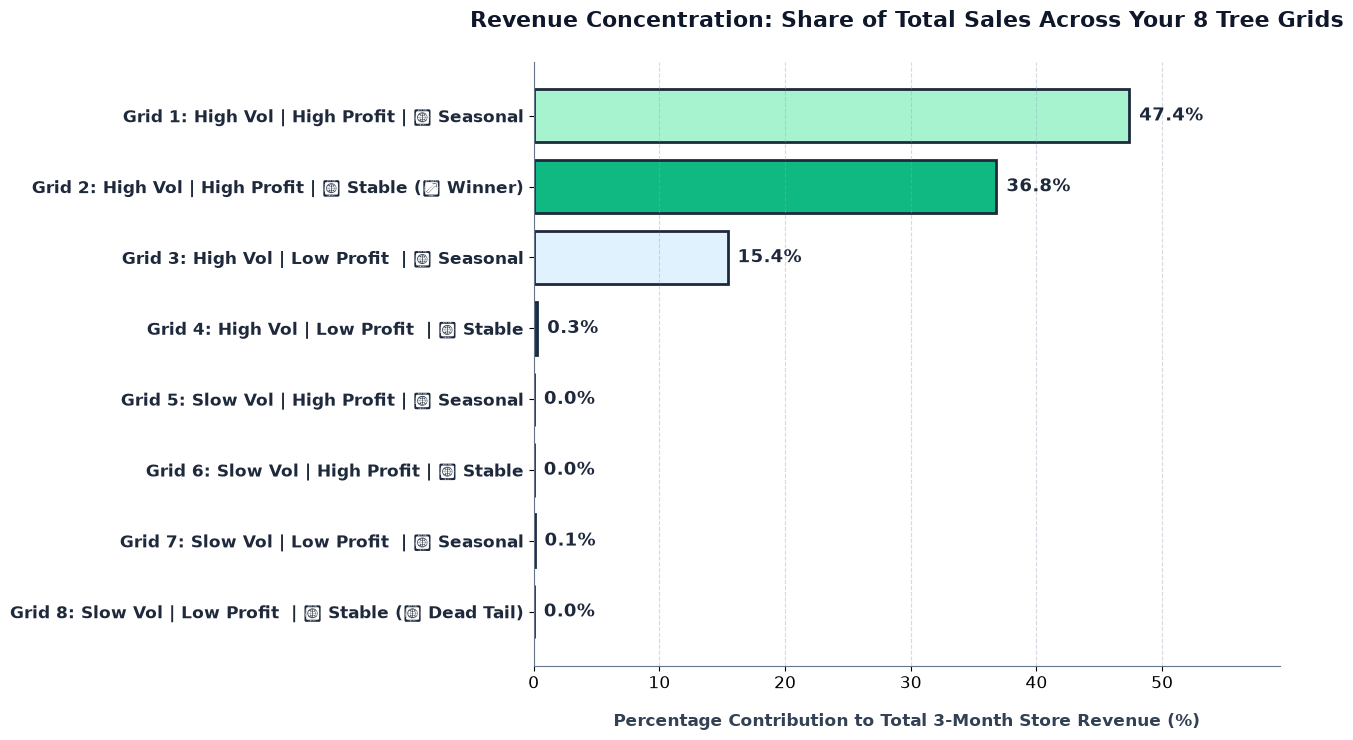

In [60]:
import matplotlib.pyplot as plt

# 1. Clean and professional row labels for your presentation slide
presentation_labels = [
    "Grid 1: High Vol | High Profit | 🍂 Seasonal",
    "Grid 2: High Vol | High Profit | 🌲 Stable (⭐ Winner)",
    "Grid 3: High Vol | Low Profit  | 🍂 Seasonal",
    "Grid 4: High Vol | Low Profit  | 🌲 Stable",
    "Grid 5: Slow Vol | High Profit | 🍂 Seasonal",
    "Grid 6: Slow Vol | High Profit | 🌲 Stable",
    "Grid 7: Slow Vol | Low Profit  | 🍂 Seasonal",
    "Grid 8: Slow Vol | Low Profit  | 🌲 Stable (🔴 Dead Tail)"
]

# Pull the percentage values calculated from your previous script
percentages = revenue_by_grid['Revenue_Percentage'].values

# 2. Setup a wider, cleaner presentation canvas
fig, ax = plt.subplots(figsize=(13, 7.5))

# A premium, vibrant designer palette (Greens for top engines, Blues for stable mid, Reds for risk)
attractive_palette = [
    "#A7F3D0",  # Light Mint Green (Grid 1)
    "#10B981",  # Deep Vibrant Emerald (Grid 2 - Clear Winner)
    "#E0F2FE",  # Soft Sky Ice Blue (Grid 3)
    "#0284C7",  # Deep Ocean Blue (Grid 4)
    "#FFEDD5",  # Soft Pastel Cream (Grid 5)
    "#F97316",  # Clean Sharp Orange (Grid 6)
    "#FEE2E2",  # Soft Pastel Rose (Grid 7)
    "#EF4444"   # Solid Warning Red (Grid 8 - Underperformers)
]

# height=0.75 makes the bars thick, bold, and distinct
bars = ax.barh(presentation_labels, percentages, height=0.75, 
               color=attractive_palette, edgecolor='#1E293B', linewidth=2)

# 3. Add large, beautifully formatted text callouts onto the tip of every bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.8, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
            va='center', ha='left', fontsize=13, fontweight='black', color='#1E293B')

# 4. Bolder typography and visual polishing
ax.set_title('Revenue Concentration: Share of Total Sales Across Your 8 Tree Grids', 
             fontsize=16, fontweight='bold', pad=25, color='#0F172A')
ax.set_xlabel('Percentage Contribution to Total 3-Month Store Revenue (%)', 
              fontsize=12, fontweight='bold', labelpad=15, color='#334155')

# Style the axes and borders to make it look modern
ax.tick_params(axis='both', which='major', labelsize=12)
plt.yticks(fontweight='bold', color='#1E293B') # Bold row labels for quick reading
ax.set_xlim(0, max(percentages) + 12)          # Leaves breathing room for the text tags
ax.invert_yaxis()                              # Places Grid 1 at the top of the chart
ax.grid(axis='x', linestyle='--', alpha=0.4, color='#94A3B8')

# Remove top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#64748B')
ax.spines['bottom'].set_color('#64748B')

# 5. Render clean dashboard plot
plt.tight_layout()
plt.show()
